In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra
using DifferentialEquations, StaticArrays

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [2]:
crypt_pbc = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        :S => Float64,
        # :S_2 => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64,
        :M => Float64,
        :Ds => Float64
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64
    ),

    medium = Dict(
        :mm => Float64,
        :ve => Float64
    ),

    agentODE = quote
  
        xmin, xmax = simBox[1,1], simBox[1,2]
        ymin, ymax = simBox[2,1], simBox[2,2]


        idx = Int(floor(Int, x/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        idy = Int(floor(Int, y/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        
        # X direction
        if x < xmin
            idx = Int(floor(Int, (x+(xmax - xmin))/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)

        elseif x > xmax
            idx = Int(floor(Int, (x-(xmax - xmin))/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)

        end

        # # Y direction
        if y < ymin
            idy = Int(floor(Int,(y+ymax-ymin)/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)

        elseif y > ymax
            idy = Int(floor(Int,(y-(ymax-ymin))/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)

        end

        mmb = max(0, mm[idx,idy])

        F = ε0 + ε1 * methyl + Nrec * log((1 + mmb / Ki) / (1 + mmb / Ka))
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)      

        mx = (ε0 + Nrec * log((1 + mmb / Ki) / (1 + mmb / Ka)) - F0) / (- ε1)
       

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))     

        dt(x) = vx 
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)     
        
    end,

    agentRule = quote

        xmin, xmax = simBox[1,1], simBox[1,2]
        ymin, ymax = simBox[2,1], simBox[2,2]

        idx = Int(floor(Int, x/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        idy = Int(floor(Int, y/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)        

        v_run = v
        v_tumble = 0.25 
        speed = active ? v_run : v_tumble

        Dr_tumble = 6.2      
        Dr_total = active ? Dr_run : Dr_tumble

        mm[idx,idy] += S

        if active 
            λ = ωFrec*exp(-G)
            P = 1 - exp(-λ * dt)
                
        else
            λ = ωFrec*exp(G)
            P = 1 - exp(-λ * dt)  
                
        end


        if active 
            λrt = ωFrec*exp(-G) 
            P_rt = 1 - exp(-λrt * dt)
            P = rand() 
                                                  
            if P < P_rt             
                active = false
                vx = speed* cos(theta) + ve[idx, idy]
                vy = speed* sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn() 
                        
            else    
                active = true
                vx = speed * cos(theta) + ve[idx, idy]
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
                     
            end

        else
            λtr = ωFrec*exp(G) 
            P_tr = 1 - exp(-λtr * dt)
            P = rand()

            if P < P_tr
                active = true
                vx = speed * cos(theta) + ve[idx, idy]
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()

            else
                active = false
                vx = speed* cos(theta) + ve[idx, idy]
                vy = speed* sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()

            end
        end

        # if x <= xmin
        #     x = xmin + (xmin - x)
        #     theta = pi - theta
        # elseif x >= xmax
        #     @removeAgent()
        # end
        if x < xmin         # PBC
            x += (xmax - xmin)
        elseif x > xmax
            x -= (xmax - xmin)
        end

        if y >= ymax
            y = 2*ymax - y
            theta = 2*pi - theta
        end

        if y <= wall_y(x, 62, 200, 250, 20, 500)
            x_new = clamp(round(Int, x/2), 1, 250)
            y_new = clamp(round(Int, y/2), 1, 250)

            if MYT[x_new, y_new] == 1 && MXR[x_new, y_new] == 1
                y = wall_y(x, 62, 200, 250, 20, 500) + 1
                x = x + 1
                theta = theta + pi

            elseif MYT[x_new, y_new] == 1 && MXL[x_new, y_new] == 1
                y = wall_y(x, 62, 200, 250, 20, 500) + 1
                x = x - 1
                theta = theta + pi

            elseif MYT[x_new, y_new] == 1 
                y = wall_y(x, 62, 200, 250, 20, 500) + 1
                theta = 2*pi - theta

            elseif MXR[x_new, y_new] == 1
                x = x + 2
                theta = pi - theta

            elseif MXL[x_new, y_new] == 1
                x = x - 2
                theta = pi - theta

            elseif M0[x_new, y_new] == 1        # Esta dins, no pinta res allí
                t0 = round(Int, (t-1))
                x_old = x[t0]
                y_old = y[t0]
                nsteps = ceil(Int, max(abs(x - x_old), abs(y - y_old)))

                hit_type = nothing

                for s in 0:nsteps
                    xs = x_old + (x - x_old) * s / nsteps
                    ys = y_old + (y - y_old) * s / nsteps

                    xi = clamp(round(Int, xs/2), 1, 250)
                    yi = clamp(round(Int, ys/2), 1, 250)

                    if MXR[xi, yi]
                        hit_type = :right
                        break
                    elseif MXL[xi, yi]
                        hit_type = :left
                        break
                    elseif MYT[xi, yi]
                        hit_type = :horizontal
                        break
                    end
                end
                if hit_type == :right
                    x = x_old
                    theta = pi - theta

                elseif hit_type == :left
                    x = x_old
                    theta = pi - theta

                elseif hit_type == :horizontal
                    y = y_old
                    theta = 2*pi - theta
                end
                                
            end
        end
    end,


    mediumODE = quote

        if @mediumInside()
    # --- geometry mask FIRST (do NOT overwrite mm itself) ---
            if M0[i1_, i2_]
                dt(mm) = 0

            else
                dt(mm) = DMedium * (@∂2(1, mm) + @∂2(2, mm)) - delta * mm - ve[i1_, i2_] * @∂(1, mm)

            end
            mm = MXR[i1_, i2_] ? mm[i1_ + 1, i2_] : mm
            mm = MXL[i1_, i2_] ? mm[i1_ - 1, i2_] : mm
            mm = MYT[i1_, i2_] ? mm[i1_, i2_ + 1] : mm
            
        elseif @mediumBorder(1,-1) # left PBC
            mm = mm[NMedium[1] - 1, i2_]

        elseif @mediumBorder(1,1) #right PBC
            mm = mm[1, i2_]

        elseif @mediumBorder(2,-1) # 0
            mm = 0

        elseif @mediumBorder(2,+1)
            mm = mm[i1_, NMedium[2] - 2]  #reflective

        end
    end,


    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Heun()
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	xₘ (Float64 medium)
	yₘ (Float64 medium)
	Ds (Float64 agent)
	F (Float64 agent)
	active (Bool agent)
	methyl (Float64 agent)
	l (Float64 agent)
	S (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	λ (Float64 agent)
	v (Float64 agent)
	A (Float64 agent)
	fx (Float64 agent)
	vx (Float64 agent)
	fy (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)
	mm (Float64 medium)
	ve (Float64 medium)


UPDATE RULES
mediumODE
 if @mediumInside()
    if

In [3]:
function wall_y(x, w, d, y0, xstart, xend)
    
    # outside wall region → flat at baseline
    if x < xstart || x > xend
        return y0
    end

    # shift x so pattern starts at xstart
    ξ = x - xstart

    # square-wave pattern (0 or -d), then shift up by y0
    return y0 - d * floor((1 + sign(sin(2π * ξ / w))) / 2)
end

wall_y (generic function with 1 method)

In [4]:
x1, x2, y1, y2 = 0, 500, 0, 500
med1, med2 = 250, 250

width = 62
depth = 200
y_start = y2/2
x_start = 20
x_end = x2
dx = (x2 - x1) / med1
dy = (y2 -y1) / med2

xcoord(i1_) = x1 + (i1_ - 1) * dx
ycoord(i2_) = y1 + (i2_ - 1) * dy
Nx = med1
Ny = med2

mask_raw = zeros(Bool, med1, med2)
M0 = zeros(Bool, med1, med2)
MXL = zeros(Bool, med1, med2)
MXR = zeros(Bool, med1, med2)
MYT = zeros(Bool, med1, med2)

for i in 1:Nx, j in 1:Ny
    x = xcoord(i)
    y = ycoord(j)
    mask_raw[i,j] = y < wall_y(x, width, depth, y_start, x_start, x_end)
end

for i in 2:Nx-1, j in 2:Ny-1
    if mask_raw[i,j] &&
    mask_raw[i+1,j] &&
    mask_raw[i-1,j] &&
    mask_raw[i,j+1] &&
    mask_raw[i,j-1] &&
    mask_raw[i+1,j+1] &&
    mask_raw[i+1,j-1] &&
    mask_raw[i-1,j+1] &&
    mask_raw[i-1,j-1]

        M0[i,j] = true
    end
end

M0[1,   :] .= true
M0[250, :] .= true
M0[1,   125:end] .= false
M0[250, 125:end] .= false
M0[:, 1] .= true

for i in 2:Nx-1, j in 2:Ny-1

    if M0[i,j] == 1

                # --- HORIZONTAL LINES ---
                # bottom edge (neighbor below is outside)
        if M0[i, j-1] == 0
            MYT[i,j] = true
        end

                # top edge (neighbor above is outside)
        if M0[i, j+1] == 0
            MYT[i,j] = true
        end


                # --- LEFT WALL ---
        if M0[i-1, j] == 0
            MXL[i,j] = true
        end


                # --- RIGHT WALL ---
        if M0[i+1, j] == 0
            MXR[i,j] = true
        end

    end
end

In [5]:
com = Community(
    crypt_pbc,
    N=1000,
    dt=0.01,
    # simBox = [-100.0 100.0; -100.0 100.0],
    simBox = [0.0 500.0; 0.0 500.0],
    # simBox = [0.0 200.0; 0.0 200.0],
    NMedium = [250,250]
    # NMedium = [100,100]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

# com.v = 20.0    #Velocitat bacteries biològica
com.v = 10.0
# com.v = 0
# com.v = 5.0
# com.v = 2.5
# com.v = 1
# com.v = 0.1

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

com.τm = 1
# com.τm = 5.0
# com.τm = 10.0
# com.τm = 30.0

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

com.DMedium = 20 # 0.5
# com.DMedium = 3.33 # 3
# com.DMedium = 1.25 # 8

com.delta = 0.005  # 0.5
# com.delta = 0.03  # 3
# com.delta = 0.08  # 8

# com.x = rand(Uniform(com.simBox[1,:]...),com.N)
# com.x = 30
# com.y = rand(Uniform(250, 500),com.N)
# com.y = 400

com.x = zeros(com.N)
com.y = zeros(com.N)

count = 0

while count < com.N
    x_try = rand(Uniform(1, 500))
    y_try = rand(Uniform(1, 500))

    # map to mask indices
    i = Int(floor(x_try / 2)) + 1
    j = Int(floor(y_try / 2)) + 1

    # bounds safety
    if i < 1 || i > 250 || j < 1 || j > 250
        continue
    end

    if M0[i, j] == 0
        count += 1
        com.x[count] = x_try
        com.y[count] = y_try
    end
end

com.theta = rand(Uniform(0,2*pi),com.N)

com.methyl .= 0.0
com.Yp .= com.K

com.active .= true 

com.S = 0.0025

ve = 2

com.ve = zeros(com.NMedium[1], com.NMedium[2])

L = 50   # thickness of transition layer (tune this)

for i1 in 1:com.NMedium[1], i2 in 1:com.NMedium[2]
    y = ycoord(i2)

    if y <= 250
        # Inside crypt → no flow
        com.ve[i1, i2] = 0.0

    elseif y < 250 + L
        # Transition region → smooth increase
        f = (y - 250) / L
        com.ve[i1, i2] = 10.0 * f^2

    else
        # Bulk lumen → full flow
        com.ve[i1, i2] = ve
    end
end

In [6]:
outfile = "c_PBC_n05_ve2.jld2"
steps = 25000

loadToPlatform!(com, preallocateAgents=1000)
com.mm = zeros(Float64, com.NMedium...)

jldopen(outfile, "w") do file

    # -------------------------
    # Main loop
    # -------------------------
    for step in 1:steps
        CellBasedModels.step!(com)
        if step%100 == 0

            stepname = @sprintf("step_%06d", step)
            g = JLD2.Group(file, stepname)

            # Agent-level arrays (length = N)
            g["x"] = copy(com.x)
            g["y"] = copy(com.y)
            g["theta"] = copy(com.theta)

            # Medium grid (saved once per step)
            g["mm_grid"] = copy(com.mm)
            
        end
    end
end


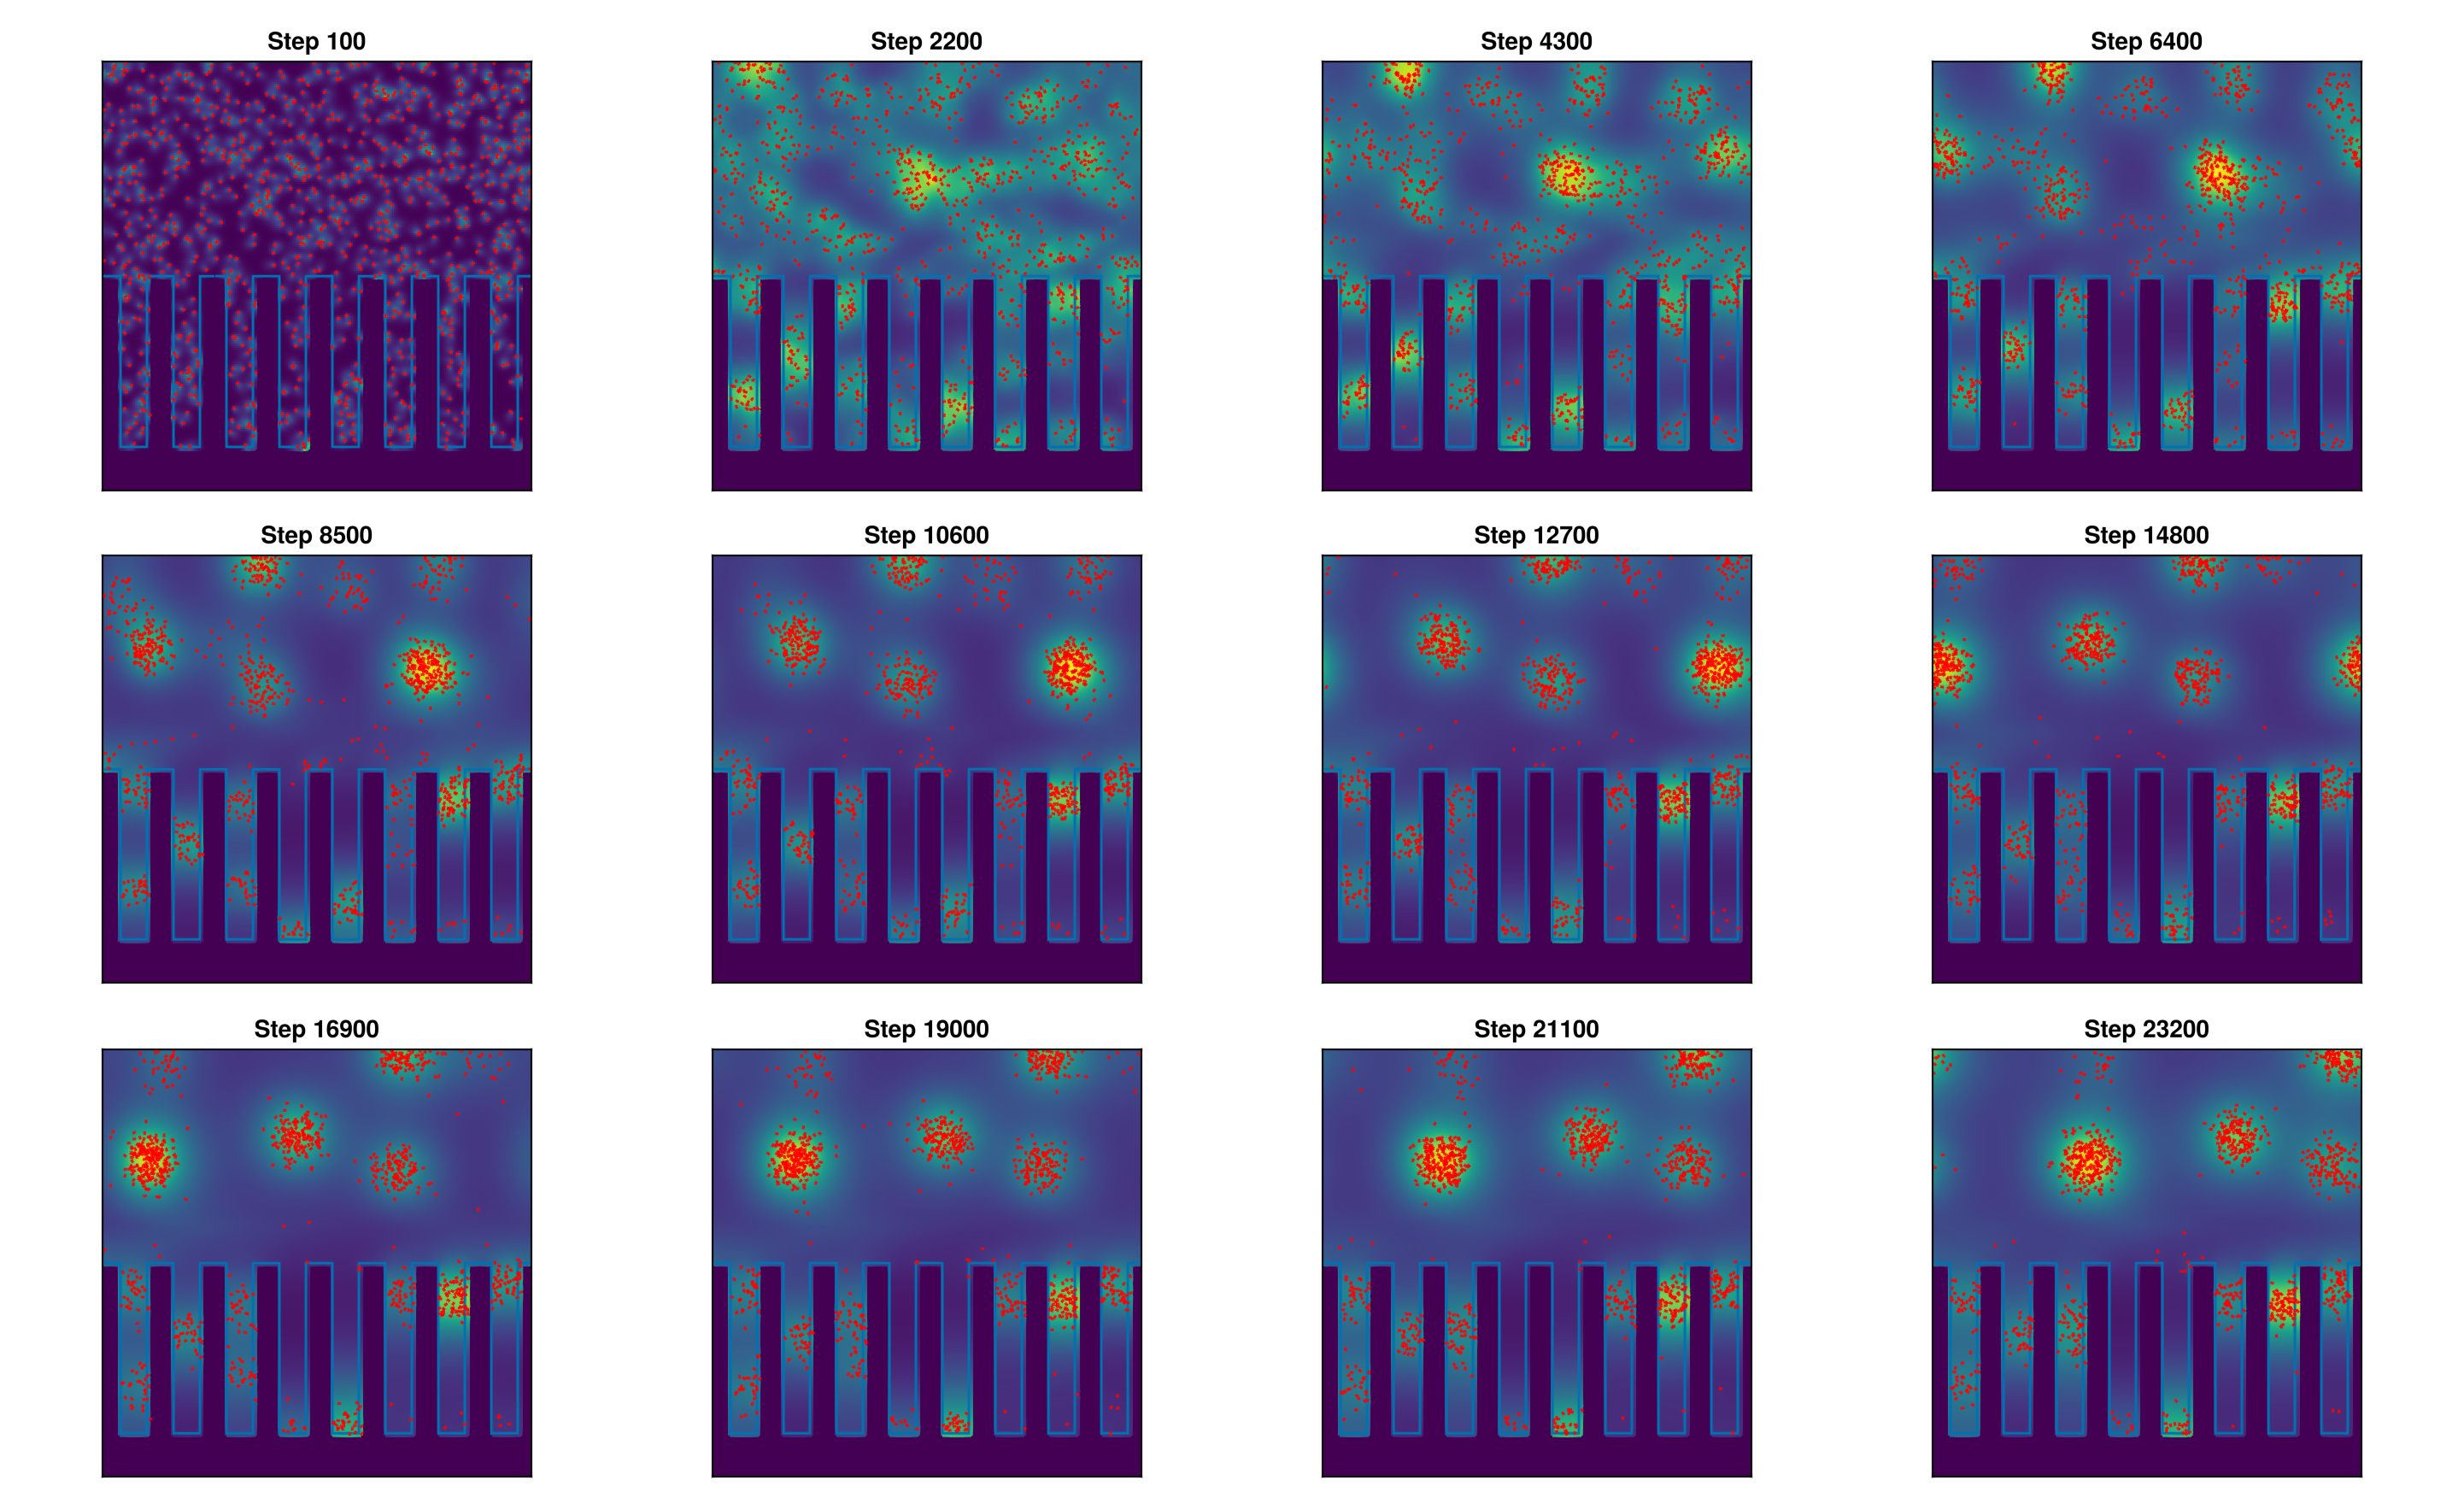

GLMakie.Screen(...)

In [7]:
fig4 = Figure(size=(900*4,600*4))

model_steps = 100:100:25000
steps_to_plot = unique(model_steps)[1:round(Int, length(unique(model_steps))/12):end]

jldopen("c_PBC_n05_ve2.jld2", "r") do file 
    for (j, step) in enumerate(steps_to_plot)

        row = ceil(Int, j / 4)
        col = (j - 1) % 4 + 1
        # col1 = columns[j]
        ax = Axis(fig4[row, col], aspect = 1, title="Step $step")

        g = file[@sprintf("step_%06d", step)]
    
        mm_grid = g["mm_grid"]
        mm = reshape(mm_grid, (com.NMedium[1], com.NMedium[2]))

        hm = heatmap!(ax, 
                    range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
                    range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
                    mm_grid, 
                    colormap=:viridis
                    )

        xs = 0:0.1:500
        ys = [wall_y(x, 62, 200, 250, 20, 500) for x in xs]

        lines!(ax, xs, ys)


        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = 3
            
        # Compute rod endpoints
        xs1 = x .+ l ./ 2 .* cos.(theta)
        ys1 = y .+ l ./ 2 .* sin.(theta)
        xs2 = x .- l ./ 2 .* cos.(theta)
        ys2 = y .- l ./ 2 .* sin.(theta)

        for i in 1:length(x)
            if x[i] != 0
                linesegments!([Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
                linesegments!([Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
            end
        end
        hidedecorations!(ax)

        # Colorbar(fig4[1, j*2], hm, label="Chemoattractant")

    end
end
Makie.inline!(true)
display(fig4)

In [8]:
save("Plots/Cripts/Next/hom_pbc_ve2_n05.png", fig4)

In [ ]:
fig4 = Figure(size=(900*4,600*4))

model_steps = 100:100:25000
steps_to_plot = unique(model_steps)[1:round(Int, length(unique(model_steps))/12):end]

jldopen("c_pbc_n_2.jld2", "r") do file 
    for (j, step) in enumerate(steps_to_plot)

        row = ceil(Int, j / 4)
        col = (j - 1) % 4 + 1
        # col1 = columns[j]
        ax = Axis(fig4[row, col], aspect = 1, title="Step $step")

        g = file[@sprintf("step_%06d", step)]
    
        mm_grid = g["mm_grid"]
        mm = reshape(mm_grid, (com.NMedium[1], com.NMedium[2]))

        hm = heatmap!(ax, 
                    range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
                    range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
                    mm_grid, 
                    colormap=:viridis
                    )

        xs = 0:0.1:500
        ys = [wall_y(x, 62, 200, 250, 20, 500) for x in xs]

        lines!(ax, xs, ys)


        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = 3
            
        # Compute rod endpoints
        xs1 = x .+ l ./ 2 .* cos.(theta)
        ys1 = y .+ l ./ 2 .* sin.(theta)
        xs2 = x .- l ./ 2 .* cos.(theta)
        ys2 = y .- l ./ 2 .* sin.(theta)

        for i in 1:length(x)
            if x[i] != 0
                linesegments!([Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
                linesegments!([Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
            end
        end
        hidedecorations!(ax)

        # Colorbar(fig4[1, j*2], hm, label="Chemoattractant")

    end
end
Makie.inline!(true)
display(fig4)

In [ ]:
save("Plots/Cripts/Test_sim/pbc_n_2.png", fig)

# Automatic sims

In [ ]:
Dc = 10
delta = 0.0025
depths = [100, 150, 200]
ve = 10
ns = [0.5, 4.0, 7.0]

for (idx, n) in enumerate(ns)

    for i in 1:length(depths)

        println("Running simulation with parameters: ", depths[i], " and ", n)

        x1, x2, y1, y2 = 0, 500, 0, 500
        med1, med2 = 250, 250

        width = 62
        depth = depths[i]
        y_start = y2/2
        x_start = 20
        x_end = x2
        dx = (x2 - x1) / med1
        dy = (y2 -y1) / med2

        xcoord(i1_) = x1 + (i1_ - 1) * dx
        ycoord(i2_) = y1 + (i2_ - 1) * dy
        Nx = med1
        Ny = med2

        mask_raw = zeros(Bool, med1, med2)
        M0 = zeros(Bool, med1, med2)
        MXL = zeros(Bool, med1, med2)
        MXR = zeros(Bool, med1, med2)
        MYT = zeros(Bool, med1, med2)

        for i in 1:Nx, j in 1:Ny
            x = xcoord(i)
            y = ycoord(j)
            mask_raw[i,j] = y < wall_y(x, width, depth, y_start, x_start, x_end)
        end

        for i in 2:Nx-1, j in 2:Ny-1
            if mask_raw[i,j] &&
            mask_raw[i+1,j] &&
            mask_raw[i-1,j] &&
            mask_raw[i,j+1] &&
            mask_raw[i,j-1] &&
            mask_raw[i+1,j+1] &&
            mask_raw[i+1,j-1] &&
            mask_raw[i-1,j+1] &&
            mask_raw[i-1,j-1]

                M0[i,j] = true
            end
        end

        
        M0[1,   :] .= true
        M0[250, :] .= true
        M0[1,   125:end] .= false
        M0[250, 125:end] .= false
        M0[:, 1] .= true

        for i in 2:Nx-1, j in 2:Ny-1

            if M0[i,j] == 1

                # --- HORIZONTAL LINES ---
                # bottom edge (neighbor below is outside)
                if M0[i, j-1] == 0
                    MYT[i,j] = true
                end

                # top edge (neighbor above is outside)
                if M0[i, j+1] == 0
                    MYT[i,j] = true
                end


                # --- LEFT WALL ---
                if M0[i-1, j] == 0
                    MXL[i,j] = true
                end


                # --- RIGHT WALL ---
                if M0[i+1, j] == 0
                    MXR[i,j] = true
                end

            end
        end

        MYT[1,   123:124] .= true
        MYT[250,   123:124] .= true

        com = Community(
            crypt_pbc,
            N=1000,
            dt=0.01,
            simBox = [x1 x2; y1 y2],
            NMedium = [med1, med2]
        )

        m = 1/100
        g = 1/10000
        d = 1

        com.Dr_run = 0.062

        com.v = 20.0    #Velocitat bacteries biològica

        com.ωFrec = 1.3
        com.Ki = 0.0182
        com.Ka = 3.0
        com.Nrec = 6.0
        com.ε0   = 6.0
        com.ε1   = -1.0
        com.ε2   = 80
        com.ε3   = 80

        com.τm = 1

        com.α   = 6.0
        com.K = 2.0 
        com.Ky = 100.0
        com.Kz = 10.0
        com.Z = 5.0
        com.Yy = 0.

        com.m = 1.        
        com.d = 1.        
        com.l = 3;

        com.DMedium = Dc / n
        com.delta = delta * n

        com.x = zeros(com.N)
        com.y = zeros(com.N)

        count = 0

        while count < com.N
            x_try = rand(Uniform(0, 500))
            y_try = rand(Uniform(0, 500))
           
            i = Int(round(Int, (x_try / 2))) + 1
            j = Int(round(Int, (y_try / 2))) + 1

            # bounds safety
            if i < 1 || i > 250 || j < 1 || j > 250
                continue
            end

            if M0[i, j] == 0
                count += 1
                com.x[count] = x_try
                com.y[count] = y_try
            end
        end
        com.theta = rand(Uniform(0, 2 * pi),com.N)
        com.active .= true 
        com.methyl .= 0.0
        com.Yp .= com.K
        com.S = 0.0025

        com.ve = zeros(com.NMedium[1], com.NMedium[2])

        L = 100.0   # thickness of transition layer (tune this)

        for i1 in 1:com.NMedium[1], i2 in 1:com.NMedium[2]
            y = ycoord(i2)

            if y <= 250
                # Inside crypt → no flow
                com.ve[i1, i2] = 0.0

            elseif y < 250 + L
                # Transition region → smooth increase
                f = (y - 250) / L
                com.ve[i1, i2] = ve * f^2

            else
                # Bulk lumen → full flow
                com.ve[i1, i2] = ve
            end
        end

        outfile = "c_PBC_n$(n)_lc_$(depths[i]).jld2"
        println("here")
        steps = 50000
        loadToPlatform!(com, preallocateAgents=1000)
        com.mm = zeros(Float64, com.NMedium...)

        # jldopen(outfile, "w") do file
            
        #     for step in 1:steps
        #         CellBasedModels.step!(com)
        #         if step % 100 == 0
        #             stepname = @sprintf("step_%06d", step)
        #             g = JLD2.Group(file, stepname)

        #             # Agent-level arrays (length = N)
        #             g["x"] = copy(com.x)
        #             g["y"] = copy(com.y)
        #             g["theta"] = copy(com.theta)

        #             # Medium grid (saved once per step)
        #             g["mm_grid"] = copy(com.mm)
        #         end
        #     end
        # end
    end
end


Running simulation with parameters: 100 and 0.5
here


BoundsError: BoundsError: attempt to access 3-element Vector{Int64} at index [5]

In [13]:
depths = [100, 150, 200]
ns = [0.5, 4.0, 7.0]
for (idx, n) in enumerate(ns)
    for (idx_d, d) in enumerate(depths)
        fig4 = Figure(size=(900*4,600*4))
        # steps = 5000
        model_steps = 100:100:50000
        steps_to_plot = unique(model_steps)[1:round(Int, length(unique(model_steps))/12):end]


        jldopen("c_PBC_n$(n)_lc_$(depths[i]).jld2", "r") do file 
            for (j, step) in enumerate(steps_to_plot)

                row = ceil(Int, j / 4)
                col = (j - 1) % 4 + 1
                # col1 = columns[j]
                ax = Axis(fig4[row, col], aspect = 1, title="Step $step")

                g = file[@sprintf("step_%06d", step)]
            
                mm_grid = g["mm_grid"]
                mm = reshape(mm_grid, (com.NMedium[1], com.NMedium[2]))

                hm = heatmap!(ax, 
                            range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
                            range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
                            mm_grid, 
                            colormap=:viridis
                            )

                xs = 0:0.1:500
                ys = [wall_y(x, 62, d, 250, 20, 500) for x in xs]

                lines!(ax, xs, ys)


                x = g["x"]
                y = g["y"]
                theta = g["theta"]
                l = 3
                    
                # Compute rod endpoints
                xs1 = x .+ l ./ 2 .* cos.(theta)
                ys1 = y .+ l ./ 2 .* sin.(theta)
                xs2 = x .- l ./ 2 .* cos.(theta)
                ys2 = y .- l ./ 2 .* sin.(theta)

                for i in 1:length(x)
                    if x[i] != 0
                        linesegments!([Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
                        linesegments!([Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
                    end
                end
                hidedecorations!(ax)

                # Colorbar(fig4[1, j*2], hm, label="Chemoattractant")

            end

        end
        save("Plots/Cripts/Test_sims/c_PBC_n$(n)_lc$(d).png", fig4)
        # Makie.inline!(true)
        # display(fig4)
    end
end

UndefVarError: UndefVarError: `i` not defined